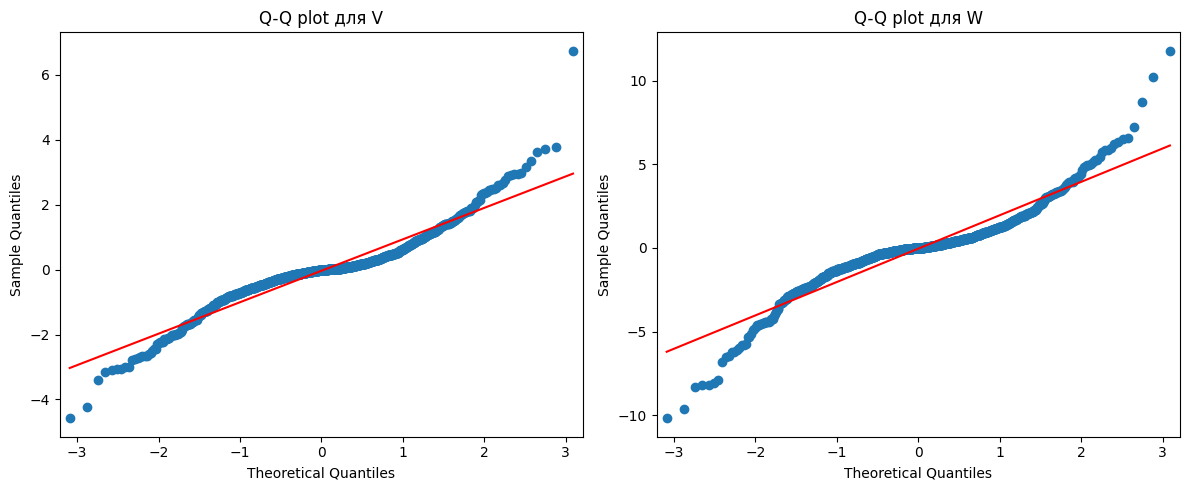

Результаты проверки нормальности:
Для V: W = 0.917, p-value = 5.398e-23
Для W: W = 0.895, p-value = 1.488e-25



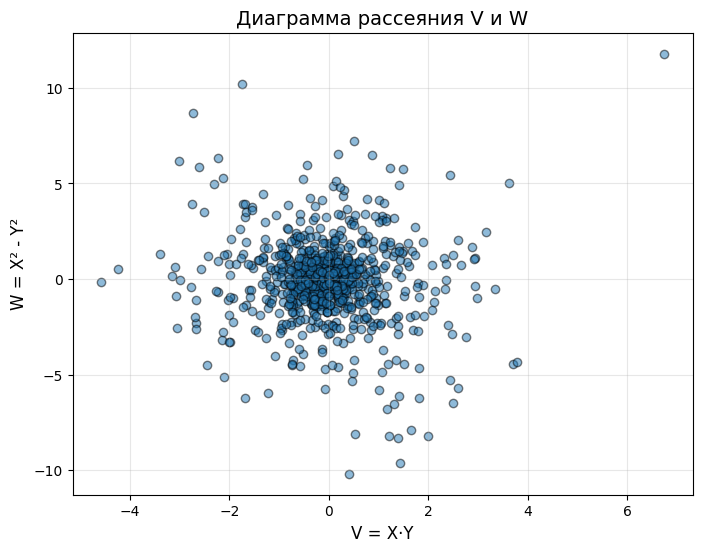

Корреляционный анализ:
Коэффициент Спирмена: ρ = -0.0261
p-value = 0.4089

Вывод: Нет оснований отвергать H₀ (корреляция незначима)


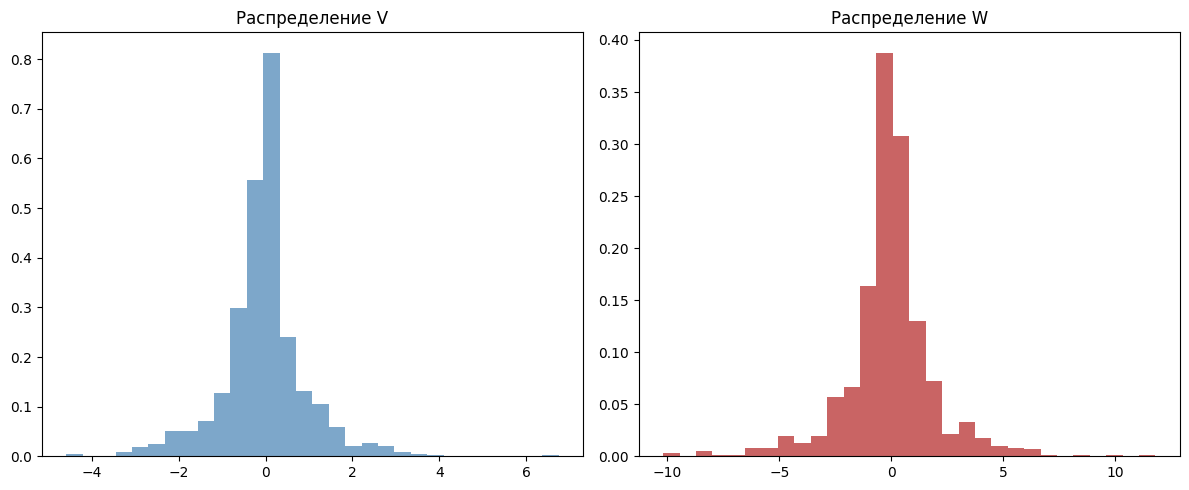

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot

# 1. Генерация данных
np.random.seed(42)
n = 1000  # объем выборки
X = np.random.normal(0, 1, n)  # X ~ N(0,1)
Y = np.random.normal(0, 1, n)  # Y ~ N(0,1), Cov(X,Y)=0
V = X * Y                       # V = X*Y
W = X**2 - Y**2                # W = X² - Y²

# 2. Проверка нормальности распределения

# 2.1. Q-Q графики
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
qqplot(V, line='s', ax=ax[0])
ax[0].set_title('Q-Q plot для V', fontsize=12)
qqplot(W, line='s', ax=ax[1])
ax[1].set_title('Q-Q plot для W', fontsize=12)
plt.tight_layout()
plt.show()

# 2.2. Критерий Шапиро-Уилка
shapiro_V = stats.shapiro(V)
shapiro_W = stats.shapiro(W)

print("Результаты проверки нормальности:")
print(f"Для V: W = {shapiro_V.statistic:.3f}, p-value = {shapiro_V.pvalue:.3e}")
print(f"Для W: W = {shapiro_W.statistic:.3f}, p-value = {shapiro_W.pvalue:.3e}\n")


# 3. Корреляционный анализ


# 3.1. Визуализация связи
plt.figure(figsize=(8, 6))
plt.scatter(V, W, alpha=0.5, edgecolor='k')
plt.title('Диаграмма рассеяния V и W', fontsize=14)
plt.xlabel('V = X·Y', fontsize=12)
plt.ylabel('W = X² - Y²', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# 3.2. Коэффициент Спирмена. Для данной задачи он лучше так как улавливает даже нелинейную связь в то время как Пирсон показывает линейную связь
spearman = stats.spearmanr(V, W)
print("Корреляционный анализ:")
print(f"Коэффициент Спирмена: ρ = {spearman.correlation:.4f}")
print(f"p-value = {spearman.pvalue:.4f}")

# 3.3. Проверка гипотезы
alpha = 0.05
if spearman.pvalue < alpha:
    print("\nВывод: Отвергаем H₀ (корреляция значима, ρ ≠ 0)")
else:
    print("\nВывод: Нет оснований отвергать H₀ (корреляция незначима)")

# 3.4. Гистограммы распределений
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(V, bins=30, density=True, alpha=0.7, color='steelblue')
ax[0].set_title('Распределение V', fontsize=12)
ax[1].hist(W, bins=30, density=True, alpha=0.7, color='firebrick')
ax[1].set_title('Распределение W', fontsize=12)
plt.tight_layout()
plt.show()